# Notebook 3: Análisis Estadístico

- El análisis estadístico se realizó en un notebook independiente con el objetivo de explorar relaciones entre variables, detectar valores atípicos y aplicar técnicas estadísticas avanzadas. 
- Este análisis permitió obtener conclusiones más profundas sobre el comportamiento del dataset.
- Cada Notebook viene con su informe en donde se aclaran o explican los aspectos relevantes y conclusiones.


## 1 Importar las librerias y la base de datos

- En este primer paso se importan las librerías necesarias para realizar análisis estadístico y visualizaciones más avanzadas.
- Se carga el dataset limpio "Proyecto_Final_Datos_limpios.csv"

In [1]:
import seaborn as sns           
import matplotlib.pyplot as plt
from scipy import stats


import pandas as pd

df = pd.read_csv('../Datos_Limpios/Proyecto_Final_Datos_Limpios.csv')


- Se vuelve a reclasificar las columnas a categoria.

In [2]:
cols_to_category = ['hotel',"meal","country_ISO-3","market_segment",
                    "distribution_channel","reserved_room_type",
                    "assigned_room_type","deposit_type","customer_type",
                    "reservation_status","Country Name","continent",
                    "family","room_change"]

for col in cols_to_category:
    if col in df.columns:
        df[col] = df[col].astype('category')

## 1. Adr (average daily rate) la variable objetivo

- ADR es la variable económica más importante del dataset, por eso se analizan sus valores en detalle. 
  - Media:     precio promedio por noche ".mean()"
  - Mediana:   precio típico sin influencia de valores extremos (outliers) ".median()"
  - Desviación estándar:  si los precios son estables o muy varirables precios ".std()"
  - Varianza:  base para las pruebas estadidticas dispersión cuadrática de los precios ".var()"
  - Cuantiles:  cómo se distribuyen los precios ".quantile([0.25, 0.5, 0.75])"


In [3]:
df['adr'].mean()

np.float64(101.83112153446687)

In [4]:
df['adr'].median()


np.float64(94.575)

In [5]:
df['adr'].std()

np.float64(50.53579028554871)

In [6]:
df['adr'].var()


np.float64(2553.8660997849593)

In [7]:
df['adr'].quantile([0.25, 0.5, 0.75])

0.25     69.290
0.50     94.575
0.75    126.000
Name: adr, dtype: float64

## 2. Boxplots para detectar Outliers

- Los boxplots permiten identificar la presencia de valores atípicos en las principales variables numéricas del dataset.
- Se selecciona las columnas "lead_time, total_stay, total_people y adr" para la elaboración de boxplots.

- Explicación del Código

  - num_cols = ['lead_time','total_stay','total_people','adr'] Se selecciona las variables numéricas más relevantes para analizar outliers.
  - plt.figure(figsize=(12,8)) Se define el tamaño de la figura para que los 4 gráficos se vean ordenados y del mismo tamaño.
  - Se utiliza un bucle con enumerate() para recorrer cada variable y ubicar su gráfico en una cuadrícula de 2×2 mediante plt.subplot().
  - Se recorre cada columna con enumerate para obtener:
    - i  posición del subplot
    - col  nombre de la variable
    - sns.boxplot(data=df, y=col) Cada boxplot permite identificar la mediana, la dispersión y los valores atípicos de la variable analizada. 
  - plt.tight_layout()  Se usa esta funcion para ajustar los espacios entre los gráficos para asegurar una visualización clara y ordenada.
  - plt.show() muestra la figura completa.

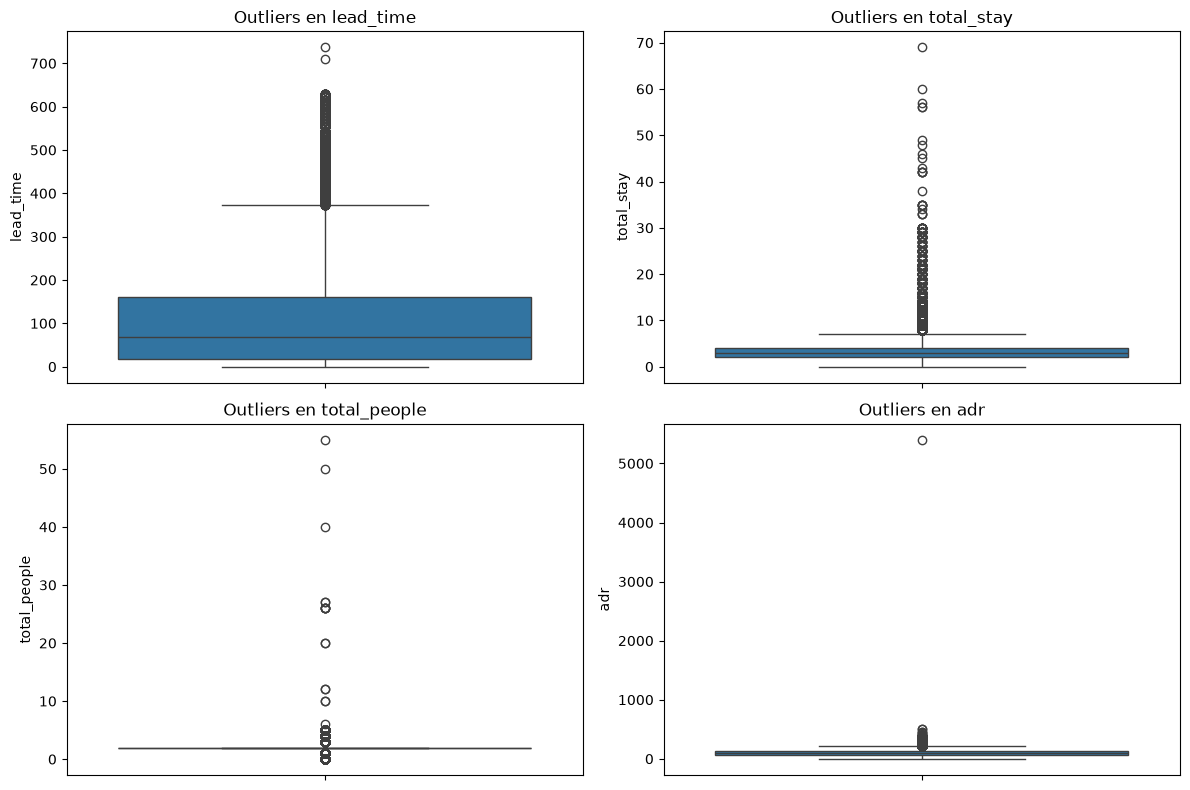

In [8]:
num_cols = ['lead_time','total_stay','total_people','adr']

plt.figure(figsize=(12,8))
for i, col in enumerate(num_cols):
    plt.subplot(2,2,i+1)
    sns.boxplot(data=df, y=col)
    plt.title(f"Outliers en {col}")
plt.tight_layout()
plt.show()


## 3. Comparaciones entre variables

- Las comparaciones de variables se realizan para entender las relaciones y diferencias entre distintos aspectos de los datos.
- Se puede descubrir patrones, asociaciones o contrastes que ayudan a responder preguntas específicas del análisis.
- Se usan boxplots para hacer las comparaciones aunque tambien tenemos graficos de barras, histogramas (aplicadas en el analisis descriptivo) o las pruebas estadisticas que las veremos a continuación.





### 1. Precio medio (adr) por contiente (continent)

- Se compara  el precio medio por noche entre los distintos continentes.

- Se crea un boxplot donde:
  - sns.boxplot(data=df, x='continent', y='adr')
  - "continent" va en el eje X (categorías) y "adr" en el eje Y (valores numéricos).


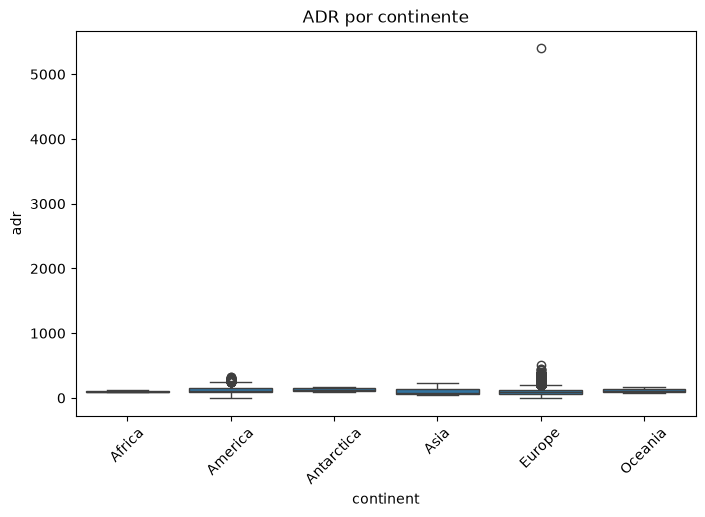

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='continent', y='adr')
plt.title("ADR por continente")
plt.xticks(rotation=45)
plt.show()


### 2. Duración de la Estancia ("total_stay") segun si son o no familia ("family")

- Se compara la duración de la estancias entre familias y no familias.
- Si la reserva esta hecha por familia "si" y si no esta hecha por familia "no"

- Se crea un boxplot donde:
  - sns.boxplot(data=df, x='family', y='total_stay')
  - "family" va en el eje X (categorías) y "total_stay" en el eje Y (valores numéricos).

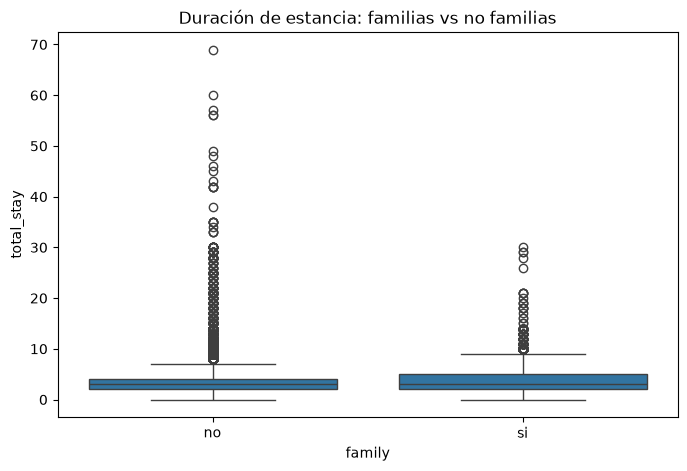

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='family', y='total_stay')
plt.title("Duración de estancia: familias vs no familias")
plt.show()


### 3. Precio medio (adr) según cambio de habitación (room_change)

- Se compara  si el cambio de habitación influye en el precio promedio.
- Si cambio la habitación " change" y si no cambio "no_change".

- Se crea un boxplot donde:
  - sns.boxplot(data=df, x='room_change', y='adr'):
    - "room_change'"es una variable categórica (eje X) que indica si el cliente cambió de habitación.
    - "adr" es la variable numérica (eje Y) que representa el precio medio por noche.


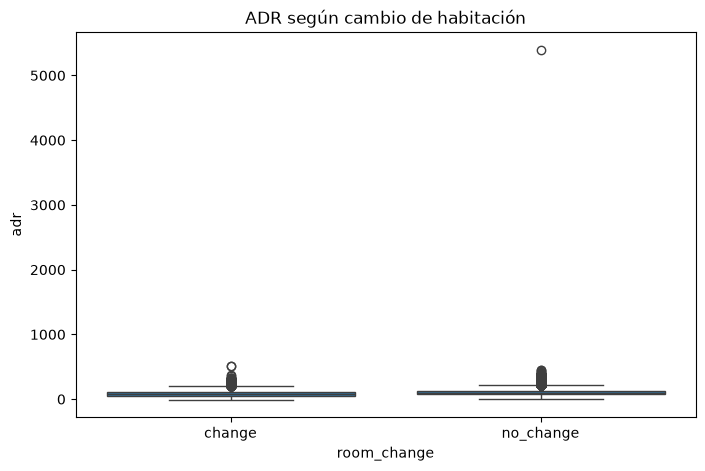

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='room_change', y='adr')
plt.title("ADR según cambio de habitación")
plt.show()


### 4. Total de personas (total_people) por continente (continent)

- Se compara la variabilidad y el comportamiento de las resevas por contiente.
- Se crea un boxplot donde:
  - sns.boxplot(data=df, x='continent', y='total_people')
  -  "continent" es el eje X (categorías) y "total_people" el eje Y (valores numéricos).


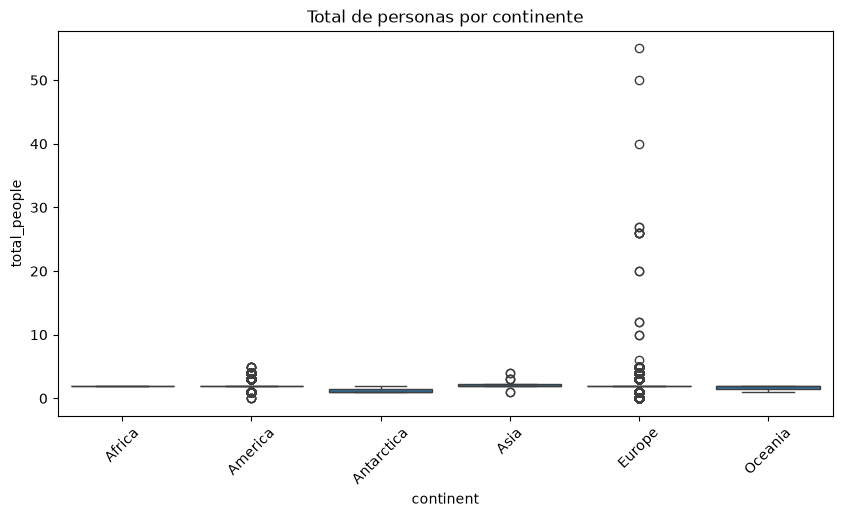

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='continent', y='total_people')
plt.title("Total de personas por continente")
plt.xticks(rotation=45)
plt.show()


## Matriz de Correlación


- Se utiliza porque permite analizar de forma rápida y visual, la relación entre todas las variables numéricas del dataset. 
- Se crea:

 - "sns.heatmap"  muestra las correlaciones entre las variables numéricas
 - "df[num_cols].corr()" calcula la matriz de correlación entre las columnas numéricas seleccionadas.
 - '"annot=True"  muestra los valores numéricos de correlación dentro de cada celda.
 - " cmap="Blues"' define los colores del mapa, en tonos azules.



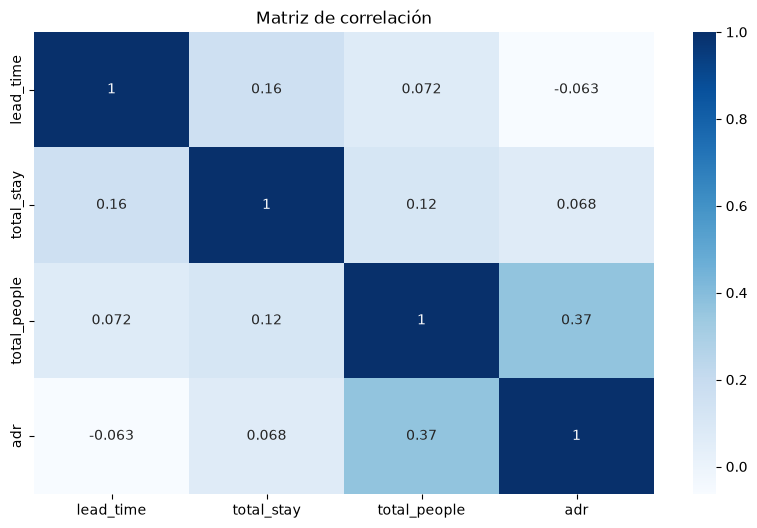

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="Blues")
plt.title("Matriz de correlación")
plt.show()


## 6. Normalidad


### 1. Prueba de Shapiro-Wilk

- La prueba sirve para evaluar si la vraible sigue una distribución normal pero es muy sensisbles por eso se hace con muestras pequeñas (< 5.000 ideal menor a 500).

- Si el p‑value < 0.05 No se rechaza la Hipotesis Nula, la variable  es Normal
- Si el p-value > 0.05 Se rechaza la normalidad, la variable No es Normal 

- Codigo:
  - df['adr'] Se selecciona la columna con la que se va trabajar
  - .sample(500)  Nuestra muestra es grande por eso solo lo aplicamos a esa muestra.
  - "stat" es el estadistico de prueba
  - "p" p-value indica si la distribucion es normal o no

In [14]:
stats.shapiro(df['adr'].sample(500))

ShapiroResult(statistic=np.float64(0.9405879786516651), pvalue=np.float64(3.0205281382916733e-13))

### 2. Prueba de Kolmogorov-Smirnov


- La prueba compara la distribución empírica de mis datos con una distribución teórica (en este caso, la normal) y mide la mayor diferencia entre ambas. Es especialmente útil cuando trabajo con muestras grandes, donde otras pruebas como Shapiro-Wilk pueden volverse demasiado sensibles.

- Si el p‑value < 0.05 No se rechaza la Hipotesis Nula, la variable  es Normal
- Si el p-value > 0.05 Se rechaza la normalidad, la variable No es Normal 

- Codigo:
 - Para aplicar precisa importar Kstest
 - kstest: Se aplica la prueba (K-S) que compara mis datos con una distribucion teórica.
 - df['adr']: Se selecciona la columnana "adr" que es la que contiene el precio medio por noche.
 - norm:  Se quiere compara mis datos contra una distribución normal.
  - stat: ( el estadistico K-S que mide la distancia entre mis distribución y la normal)
- p: p-value que mide si esa diferencia es significativa.

In [15]:
from scipy.stats import kstest


stat, p = kstest(df['adr'], 'norm')
print("K-S p-value ADR:", p)

K-S p-value ADR: 0.0


### 3.  Asimetria Skewness

- La asimetría indica si la mayoría de los valores están concentrados en un extremo, si existen colas largas hacia la derecha o hacia la izquierda.
- Valores cercanos a cero indica simetría (normalidad) y valores mayores a 1 indican fuerte asimetría

- Codigo:
 - num_cols = ['...']: Seguimos trabajando con nuestra lista de variables numericas
 - print("Skewness:"): Se hace esto para ver el texto en consola pq despues vienen los valores
 - skew() : Se calcula la simetria de cada una de esas columnas




Recordar mis lista con los nombres de las variables numéricas

In [16]:
print(num_cols)

['lead_time', 'total_stay', 'total_people', 'adr']


In [17]:

print("Skewness:")
print(df[num_cols].skew())




Skewness:
lead_time        1.346550
total_stay       3.308771
total_people    10.154167
adr             10.530214
dtype: float64


### 4. Interpreatción de Kurtosis-Curtosis

- La curtosis me indica si la distribución es más picuda o más plana que una distribución normal, y especialmente si contiene outliers que afectan el análisis estadístico. Esta medida complementa la asimetría (skewness)

- Si el resultado es:
   - Kurt < 0  distribución más plana que la normal
   - Kurt > 0 distribución más picuda
   - Kurt = 0  similar a la distribución normal

- Codigo:
- kurt(): Se  mide el “apuntamiento” de la distribución, si tiene colas o valores extremos.

In [18]:
print("Kurtosis:")
print(df[num_cols].kurt())



Kurtosis:
lead_time          1.696449
total_stay        28.873721
total_people     554.650474
adr             1013.189851
dtype: float64


### 5. Q-Q plot para ADR

- Esta es prueba visual de  evaluar los datos para saber si  siguen una distribución normal. 
- El Q–Q plot  permite ver directamente cómo se comportan los cuantiles reales frente a los cuantiles teóricos de una distribución normal. 
- Si los puntos se alinean con la línea recta, la distribución es aproximadamente normal; 
- Si se curvan o se alejan, significa que hay desviaciones importantes, como asimetría o valores extremos. 

Codigo:
- df['adr'] : Se selecciona la columna que se va analizar
- stats.probplotdist="norm": Se genra un Q-Q plot que compra los cuantiles de mis datos con los cuantiles de una distribucion normal
- plot=plt: Se indica que el grafico sea de Matplotlib


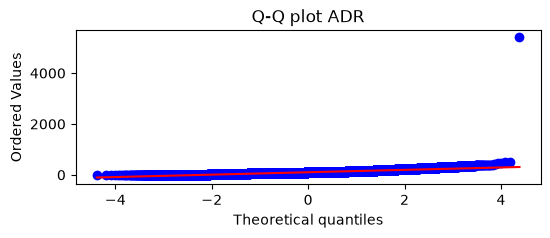

In [19]:
plt.figure(figsize=(6,2))
stats.probplot(df['adr'], dist="norm", plot=plt)
plt.title("Q-Q plot ADR")
plt.show()


## 6. Prueba de Chi-cuadrado

- Se analiza la probabilidad de que  una reserva pueda ser cancelada dependa del continente del cliente. 
- Por tanto:
	- Si el p‑value < 0.05 No se rechaza la Hipotesis Nula, son variables Independientes
	- Si el p-value > 0.05 Se rechaza la normalidad, son variables Dependientes

- Codigo:
 - from scipy.stats import chi2_contingency: Se importa la funcion que realiza la prueba d Chi-cuadrado entre dos variables ( continent y is_canceled)
 - tabla = pd.crosstab(df['continent'], df['is_canceled']): Se crea una tabla de contingencia 
 - pd.crosstab : cuenta cuntas reservas hay en cada combinacion de contiente y cancelacion.Se obtiene una tabla( filas= continente y columna= cancelado/no cancelado)
 - chi2, p, dof, expected = chi2_contingency(tabla)
      - chi2: el estadístico Chi-cuadrado.
      - p: el p-value de la prueba.
      - dof: los grados de libertad.
      - expected: la tabla de frecuencias esperadas si no hubiera relación entre las variables.




In [20]:
from scipy.stats import chi2_contingency
tabla = pd.crosstab(df['continent'], df['is_canceled'])
chi2, p, dof, expected = chi2_contingency(tabla)
print("Chi-cuadrado p-value:", p)


Chi-cuadrado p-value: 2.771356126135543e-59


## 7. Comparación de medias: T- test

- Es una prueba clásica para comparar  las medias de dos grupos independientes "adr" con "City Hotel y Resort Hotel"

- Se compara si el precio promedio por noche ("adr") es diferente entre los dos tipos de hotel: City Hotel y Resort Hotel. Donde cada grupo representa un tipo de alojamiento distinto, y el t-test me permite evaluar si las diferencias observadas en sus precios son reales y estadísticamente significativas, o si podrían deberse al azar.

- Esta comparación es importante para entender el comportamiento del mercado y analizar si el tipo de hotel influye en el valor del ADR.


- Por tanto:
	- Si el p‑value < 0.05 La diferencia entre las medias es significativa. Los grupos no tienen la misma media.
	- Si el p-value > 0.05 No hay diferencia significativa.  Las medias pueden considerarse iguales.


Codigo:

- city_adr = df[df['hotel']=="City Hotel"]['adr']: Se crea city_Adr deonde se van a filtar las filas donde el hotel es " City Hotel" y seleccionamos la columna "adr"
- resort_adr = df[df['hotel']=="Resort Hotel"]['adr'] : Se hace lo mismo pero con "Resort"

- stats.ttest_ind(city_adr, resort_adr, ...): Se usa ttest que compra si las medias de dos grupos son estadisticamente diferentes

- equal_var=False : Se indica que las varianzas no son iguales




In [21]:
city_adr = df[df['hotel']=="City Hotel"]['adr']
resort_adr = df[df['hotel']=="Resort Hotel"]['adr']

stats.ttest_ind(city_adr, resort_adr, equal_var=False)


TtestResult(statistic=np.float64(30.108490655258127), pvalue=np.float64(1.059259429311888e-197), df=np.float64(61031.63357818159))

## 8. Pruebas de proporciones  Z-Test

- Evalua si la diferencia entre las proporciones observadas es lo suficientemente grande como para considerarse estadísticamente significativa y no producto del azar. 
- Esta prueba es adecuada cuando los tamaños de muestra son grandes, como ocurre en este dataset, y por eso es una herramienta más precisa para analizar diferencias en tasas de cancelación.

- Se va a comparar si la tasa de cancelación es diferente entre el City Hotel y el Resort Hotel.

- Esta prueba está diseñada específicamente para comparar proporciones entre dos grupos, es decir, la frecuencia con la que ocurre un evento (en este caso, la cancelación) en cada hotel.

- Por tanto:
	- Si el p‑value < 0.05 Se rechaza la hipótesis nula.La diferencia es significativa
	- Si el p-value > 0.05 No se rehaza. La diferencia no es significativa.

- Codigo:

- city/hotel = df[df['hotel']=="City Hotel"]['is_canceled'] : Se selecciona todas las rservas de city y hotel que indica si la rserva fue o no cancelada
- count = [city.sum(), resort.sum()]: Se calculan cunatas reservas se cancelaron  en city y resort
- nobs = [len(city), len(resort)]: Se guarda le tamaño de cada una de ellas
- z_stat, p = sm.stats.proportions_ztest(count, nobs) : Se aplica el Z-test que comprar si las tasas de cancelacion son diferentes entre los dos hoteles ( Ho las cancelaciones son iguales y H1 son difrentes)
 


In [22]:
import statsmodels.api as sm

city = df[df['hotel']=="City Hotel"]['is_canceled']
resort = df[df['hotel']=="Resort Hotel"]['is_canceled']

count = [city.sum(), resort.sum()]
nobs = [len(city), len(resort)]

z_stat, p = sm.stats.proportions_ztest(count, nobs)

print("Z-test proporciones p-value:", p)


Z-test proporciones p-value: 0.0


## 9. Intervalo de confianza del 95 % del adr

- Cuando se quiere estimar el rango en el que se encuentra el valor promedio real del ADR en la población, da un rango con un 95% de confianza de que es verdadero.

- Interpretación del IC 95%:
- Representa el rango donde se encuentra el valor verdadero con un 95% de confianza.
- Si los intervalos de dos grupos no se solapan, existe una diferencia significativa.
- Complementa el p-value mostrando la magnitud y precisión de la estimación.




- la media del ADR (mean)
- la desviación estándar (std)
- el tamaño de la muestra (n)
- el error estándar: (std / sqrt(n))
- la distribución normal para un nivel de confianza del 95%



In [23]:
import numpy as np

mean = df['adr'].mean()
std = df['adr'].std()
n = len(df['adr'])

ci = stats.norm.interval(0.95, loc=mean, scale=std/np.sqrt(n))
print("IC 95% ADR:", ci)


IC 95% ADR: (np.float64(101.54446412186529), np.float64(102.11777894706846))
